# Step#1 Load and inspect Data


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("insurance.csv")

In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
df.shape

(1338, 7)

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [9]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Step#2: Null values


In [11]:
df.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [13]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [14]:
for i in df.columns:
    print(i, df[i].dtypes, df[i].isna().sum())

age int64 0
sex object 0
bmi float64 0
children int64 0
smoker object 0
region object 0
charges float64 0


In [15]:

import seaborn as sns
import matplotlib.pyplot as plt

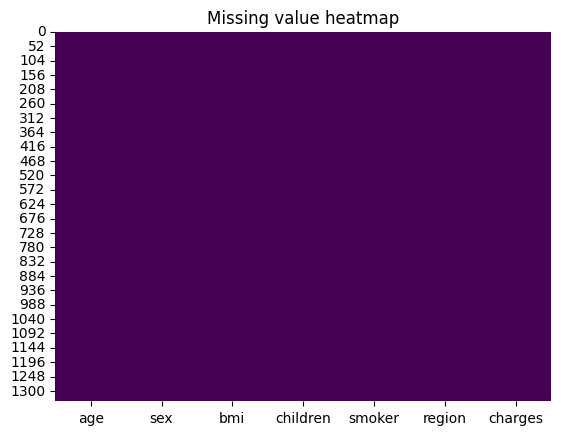

In [16]:
sns.heatmap(df.isnull(), cbar = False , cmap = "viridis")
plt.title("Missing value heatmap")
plt.show()

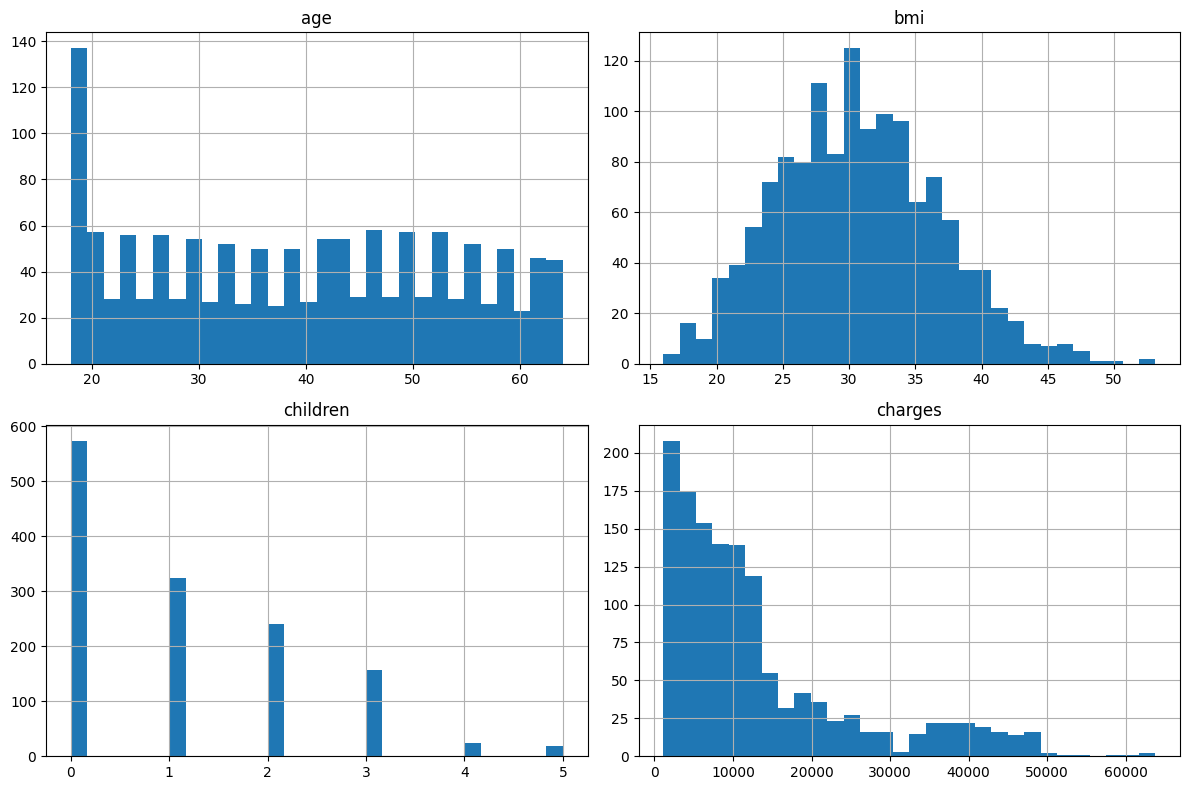

In [17]:
df.hist(figsize = (12,8), bins = 30)
plt.tight_layout()
plt.show()

# Categorical columns.

In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [19]:
for i in df:
    if(df[i].dtypes == 'object'):
        df[i] = le.fit_transform(df[i])
        print(i,df[i].dtypes )

sex int64
smoker int64
region int64


In [20]:
df = pd.get_dummies(df, drop_first=True)

In [21]:
correlation = df.corr()
correlation

,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.002127,0.299008
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.004588,0.057292
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.157566,0.198341
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.016569,0.067998
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,-0.002181,0.787251
region,0.002127,0.004588,0.157566,0.016569,-0.002181,1.000000,-0.006208
charges,0.299008,0.057292,0.198341,0.067998,0.787251,-0.006208,1.000000


<Axes: >

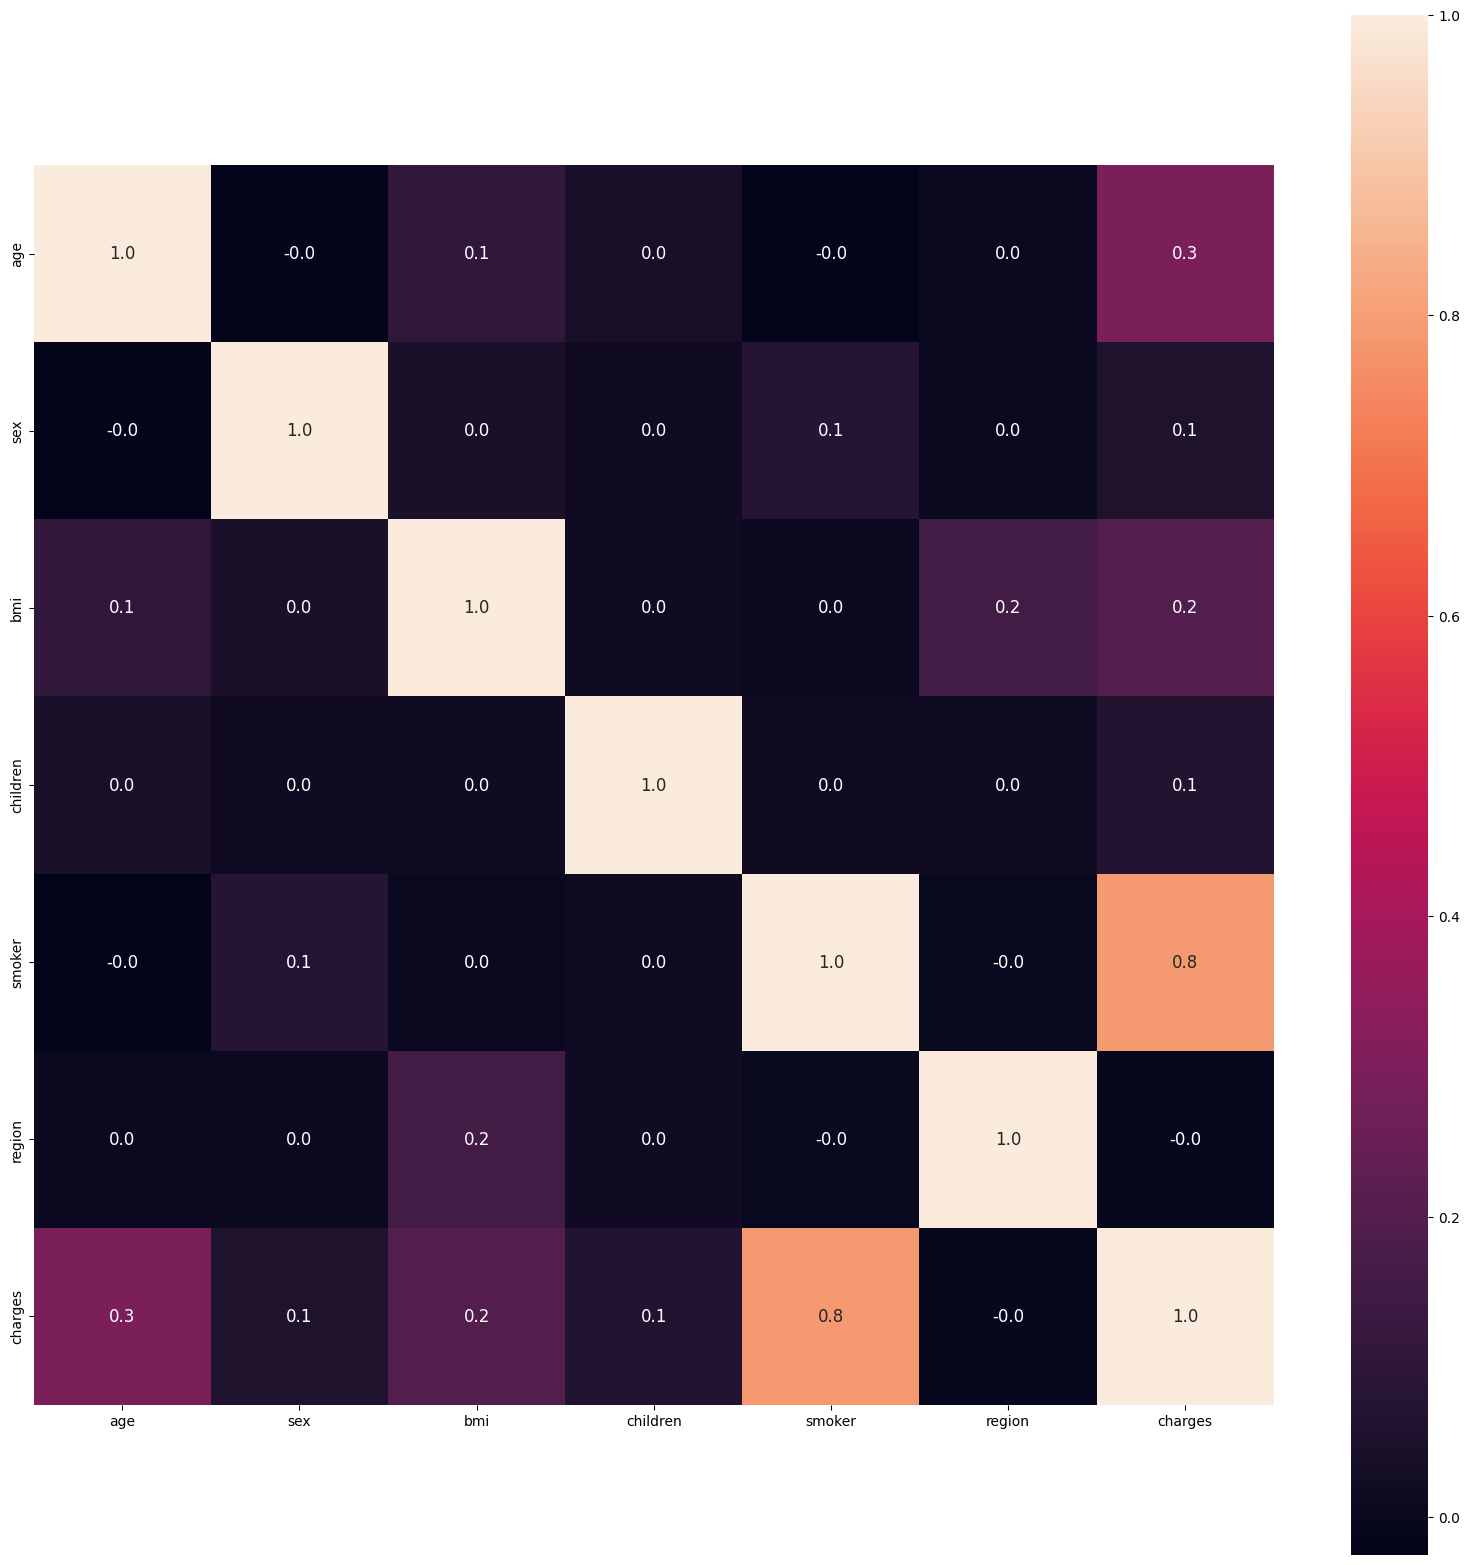

In [22]:
plt.figure(figsize=(20,20))
sns.heatmap(correlation , square = True, fmt = '.1f',annot = True, annot_kws = {'size':12})

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB


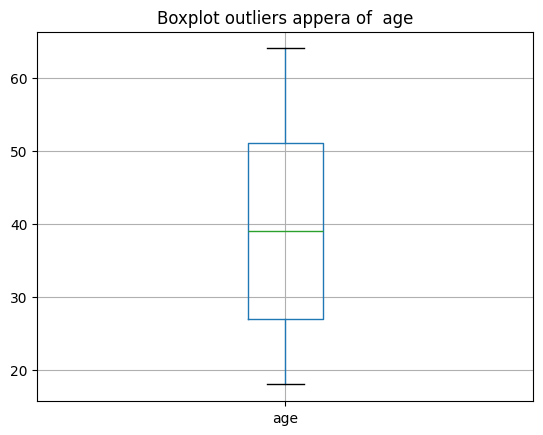

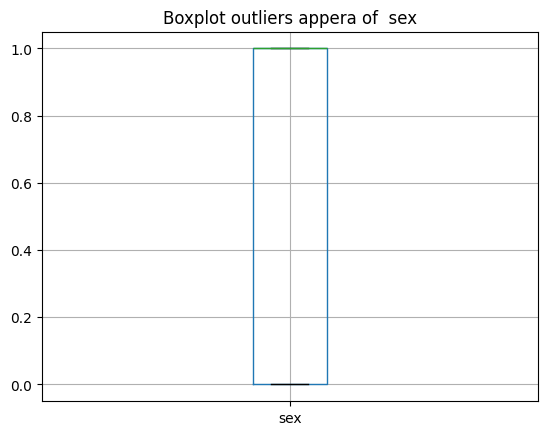

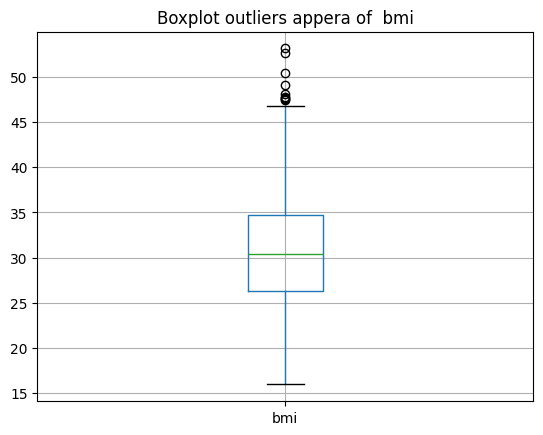

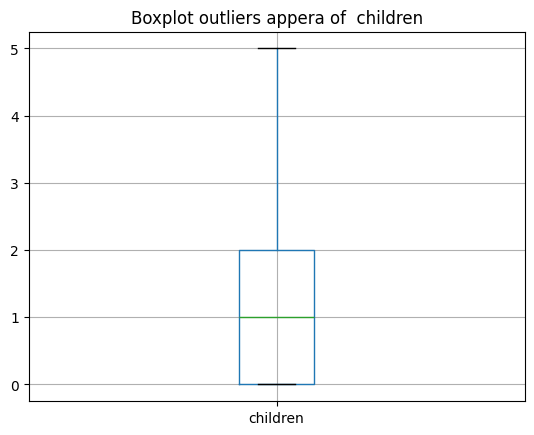

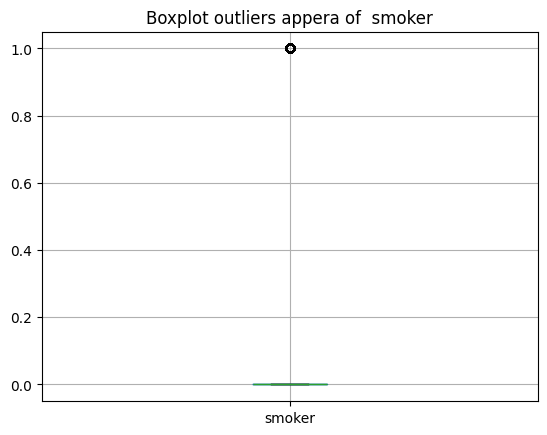

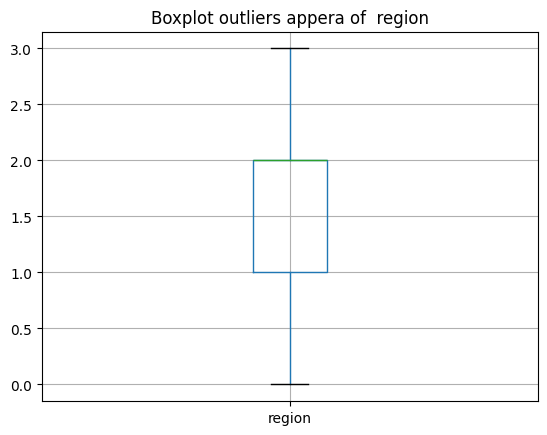

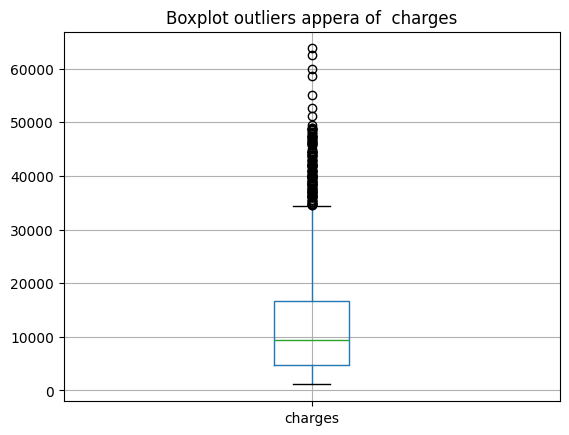

In [24]:
for i in df.columns:
    pd.DataFrame(df[i]).boxplot()
    plt.title("Boxplot outliers appera of  " + i)
    plt.show()

# Feature engineering.

In [25]:
df['bmi_smoker'] = df['bmi'] * df['smoker']

In [26]:
df['age_squared'] = df['age'] ** 2

In [27]:
df['log_charges'] = np.log(df['charges'])

In [28]:
X = df.drop(['charges', 'log_charges'], axis=1)

y = df['log_charges']

len(X)


1338

In [29]:
len(y)

1338

# Train/Split

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# XGB Boost

In [34]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [35]:
training_data_prediction_XGB = xgb.predict(X_train)
print(training_data_prediction_XGB)

[ 9.114069   9.224968   9.3406515 ...  9.397909  10.613103   9.340042 ]


In [36]:
from sklearn.metrics import(
mean_absolute_error, mean_squared_error, r2_score,
mean_absolute_percentage_error
)

In [37]:
Train_r2_Xgb = r2_score(y_train, training_data_prediction_XGB)
Train_mea_Xgb = mean_absolute_error(y_train, training_data_prediction_XGB)
Train_mse_Xgb = mean_squared_error (y_train, training_data_prediction_XGB)
Train_rmse_Xgb = np.sqrt(Train_mse_Xgb)
print(f"R2 : {Train_r2_Xgb : .4f}")
print (f"MAE : {Train_mea_Xgb: .4f}")
print(f"MSE : {Train_mse_Xgb : .4f}")
print(f"RMSE : {Train_rmse_Xgb : .4f}")

R2 :  0.8733
MAE :  0.1686
MSE :  0.1052
RMSE :  0.3243


In [38]:
y_pred_Xgb = xgb.predict(X_test)
y_pred_Xgb[: 5]

array([ 9.248987,  8.624988, 10.207863,  9.152325, 10.355367],
      dtype=float32)

In [39]:
Test_r2_Xgb = r2_score(y_test, y_pred_Xgb)
Test_mea_Xgb = mean_absolute_error(y_test, y_pred_Xgb)
Test_mse_Xgb = mean_squared_error (y_test, y_pred_Xgb)
Test_rmse_Xgb = np.sqrt(Test_mse_Xgb)
print(f"R2 : {Test_r2_Xgb : .4f}")
print (f"MAE : {Test_mea_Xgb: .4f}")
print(f"MSE : {Test_mse_Xgb : .4f}")
print(f"RMSE : {Test_rmse_Xgb : .4f}")

R2 :  0.8668
MAE :  0.1796
MSE :  0.1197
RMSE :  0.3460


In [40]:
# Random forest

In [42]:
from sklearn.ensemble import RandomForestRegressor

In [43]:
regressor = RandomForestRegressor (n_estimators = 100, random_state = 42)
regressor.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [44]:
training_data_prediction_RF = regressor.predict(X_train)
print(training_data_prediction_RF)

[ 9.16596978  9.18304514  9.7197954  ...  9.43407709 10.71427845
  9.27851038]


In [45]:
Train_r2_RF = r2_score(y_train, training_data_prediction_RF)
Train_mea_RF = mean_absolute_error(y_train, training_data_prediction_RF)
Train_mse_RF = mean_squared_error (y_train, training_data_prediction_RF)
Train_rmse_RF = np.sqrt(Train_mse_RF)
print(f"R2 : {Train_r2_RF : .4f}")
print (f"MAE : {Train_mea_RF: .4f}")
print(f"MSE : {Train_mse_RF : .4f}")
print(f"RMSE : {Train_rmse_RF : .4f}")

R2 :  0.9679
MAE :  0.0803
MSE :  0.0267
RMSE :  0.1634


In [46]:
y_pred_RF = regressor.predict(X_test)
y_pred_RF[: 5]

array([ 9.18270395,  8.52567214, 10.24705211,  9.15696328, 10.45004009])

In [47]:
Test_r2_RF = r2_score(y_test, y_pred_RF)
Test_mea_RF = mean_absolute_error(y_test, y_pred_RF)
Test_mse_RF = mean_squared_error (y_test, y_pred_RF)
Test_rmse_RF = np.sqrt(Test_mse_RF)
print(f"R2 : {Test_r2_RF : .4f}")
print (f"MAE : {Test_mea_RF: .4f}")
print(f"MSE : {Test_mse_RF : .4f}")
print(f"RMSE : {Test_rmse_RF : .4f}")

R2 :  0.8474
MAE :  0.1846
MSE :  0.1372
RMSE :  0.3705


In [48]:
# Ridge regression

In [49]:
from sklearn.linear_model import Ridge


In [50]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

Ridge()

In [51]:
training_data_prediction_Rg = ridge.predict(X_train)
print(training_data_prediction_Rg)

[ 9.17392581  9.10012962  9.15200452 ...  9.32617208 11.22037801
  9.1121634 ]


In [53]:
Train_r2_Rg = r2_score(y_train, training_data_prediction_Rg)
Train_mea_Rg = mean_absolute_error(y_train, training_data_prediction_Rg)
Train_mse_Rg = mean_squared_error (y_train, training_data_prediction_Rg)
Train_rmse_Rg = np.sqrt(Train_mse_Rg)
print(f"R2 : {Train_r2_Rg : .4f}")
print (f"MAE : {Train_mea_Rg: .4f}")
print(f"MSE : {Train_mse_Rg: .4f}")
print(f"RMSE : {Train_rmse_Rg : .4f}")

R2 :  0.7749
MAE :  0.2707
MSE :  0.1869
RMSE :  0.4324


In [54]:
y_pred_Rg = ridge.predict(X_test)
y_pred_Rg[: 5]

array([ 9.20805711,  8.69838033, 10.89623742,  9.18615562,  9.54823326])

In [55]:
Test_r2_Rg = r2_score(y_test, y_pred_Rg)
Test_mea_Rg = mean_absolute_error(y_test, y_pred_Rg)
Test_mse_Rg = mean_squared_error (y_test, y_pred_Rg)
Test_rmse_Rg = np.sqrt(Test_mse_Rg)
print(f"R2 : {Test_r2_Rg : .4f}")
print (f"MAE : {Test_mea_Rg: .4f}")
print(f"MSE : {Test_mse_Rg : .4f}")
print(f"RMSE : {Test_rmse_Rg : .4f}")

R2 :  0.8164
MAE :  0.2630
MSE :  0.1651
RMSE :  0.4063


In [56]:
# Decission Tree

In [57]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, random_state=42)

In [58]:
training_data_prediction_dt = dt.predict(X_train)
print(training_data_prediction_dt)

[ 9.01628936  9.24470488  9.40977649 ...  9.40977649 10.73952816
  9.40977649]


In [59]:
Train_r2_dt = r2_score(y_train, training_data_prediction_dt)
Train_mea_dt = mean_absolute_error(y_train, training_data_prediction_dt)
Train_mse_dt = mean_squared_error (y_train, training_data_prediction_dt)
Train_rmse_dt = np.sqrt(Train_mse_dt)
print(f"R2 : {Train_r2_dt : .4f}")
print (f"MAE : {Train_mea_dt: .4f}")
print(f"MSE : {Train_mse_dt : .4f}")
print(f"RMSE : {Train_rmse_dt : .4f}")

R2 :  0.8447
MAE :  0.2008
MSE :  0.1290
RMSE :  0.3591


In [60]:
y_pred_dt = dt.predict(X_test)
y_pred_dt[: 5]

array([ 9.01628936,  8.71558166, 10.16491451,  9.01628936, 10.44057616])

In [61]:
Test_r2_dt = r2_score(y_test, y_pred_dt)
Test_mea_dt = mean_absolute_error(y_test, y_pred_dt)
Test_mse_dt = mean_squared_error (y_test, y_pred_dt)
Test_rmse_dt = np.sqrt(Test_mse_dt)
print(f"R2 : {Test_r2_dt : .4f}")
print (f"MAE : {Test_mea_dt: .4f}")
print(f"MSE : {Test_mse_dt : .4f}")
print(f"RMSE : {Test_rmse_dt : .4f}")

R2 :  0.8323
MAE :  0.2244
MSE :  0.1508
RMSE :  0.3883


In [62]:
# SVr

In [63]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [64]:
# svr = SVR(kernel = 'linear')
# svr.fit(X_train,y_train)
svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr',    SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1))
])
svr.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('svr', SVR(C=100, gamma=0.1))])

In [65]:
training_data_prediction_svr = svr.predict(X_train)
print(training_data_prediction_svr)

[ 9.12694728  9.15197605  9.27997721 ...  9.4707551  10.6388173
  9.3306957 ]


In [66]:
Train_r2_svr = r2_score(y_train, training_data_prediction_svr)
Train_mea_svr= mean_absolute_error(y_train, training_data_prediction_svr)
Train_mse_svr = mean_squared_error (y_train, training_data_prediction_svr)
Train_rmse_svr = np.sqrt(Train_mse_svr)
print(f"R2 : {Train_r2_svr : .4f}")
print (f"MAE : {Train_mea_svr: .4f}")
print(f"MSE : {Train_mse_svr : .4f}")
print(f"RMSE : {Train_rmse_svr : .4f}")

R2 :  0.8530
MAE :  0.1558
MSE :  0.1221
RMSE :  0.3494


In [67]:
y_pred_svr = svr.predict(X_test)
y_pred_svr[: 5]

array([ 9.1733661 ,  8.59638402, 10.33105224,  9.19664375, 10.14146851])

In [68]:
Test_r2_svr = r2_score(y_test, y_pred_svr)
Test_mea_svr = mean_absolute_error(y_test, y_pred_svr)
Test_mse_svr = mean_squared_error (y_test, y_pred_svr)
Test_rmse_svr = np.sqrt(Test_mse_svr)
print(f"R2 : {Test_r2_svr : .4f}")
print (f"MAE : {Test_mea_svr: .4f}")
print(f"MSE : {Test_mse_svr : .4f}")
print(f"RMSE : {Test_rmse_svr : .4f}")

R2 :  0.8543
MAE :  0.1687
MSE :  0.1310
RMSE :  0.3619


In [69]:
# Linear Regression

In [70]:
from sklearn.linear_model import LinearRegression

In [71]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [72]:
training_data_prediction_lr = model.predict(X_train)
print(training_data_prediction_lr)

[ 9.17291298  9.09946025  9.15138218 ...  9.32534725 11.21506157
  9.11180808]


In [73]:
Train_r2_lr = r2_score(y_train, training_data_prediction_lr)
Train_mea_lr= mean_absolute_error(y_train, training_data_prediction_lr)
Train_mse_lr = mean_squared_error (y_train, training_data_prediction_lr)
Train_rmse_lr = np.sqrt(Train_mse_lr)
print(f"R2 : {Train_r2_lr : .4f}")
print (f"MAE : {Train_mea_lr: .4f}")
print(f"MSE : {Train_mse_lr : .4f}")
print(f"RMSE : {Train_rmse_lr : .4f}")

R2 :  0.7749
MAE :  0.2707
MSE :  0.1869
RMSE :  0.4323


In [74]:
y_pred_lr = model.predict(X_test)
y_pred_lr[: 5]

array([ 9.2075545 ,  8.6982821 , 10.89799423,  9.18552774,  9.54807662])

In [75]:
Test_r2_lr = r2_score(y_test, y_pred_lr)
Test_mea_lr = mean_absolute_error(y_test, y_pred_lr)
Test_mse_lr = mean_squared_error (y_test, y_pred_lr)
Test_rmse_lr = np.sqrt(Test_mse_lr)
print(f"R2 : {Test_r2_lr : .4f}")
print (f"MAE : {Test_mea_lr: .4f}")
print(f"MSE : {Test_mse_lr : .4f}")
print(f"RMSE : {Test_rmse_lr : .4f}")

R2 :  0.8165
MAE :  0.2630
MSE :  0.1650
RMSE :  0.4062


**Scatter ploting the predicting vlaues and actual values**

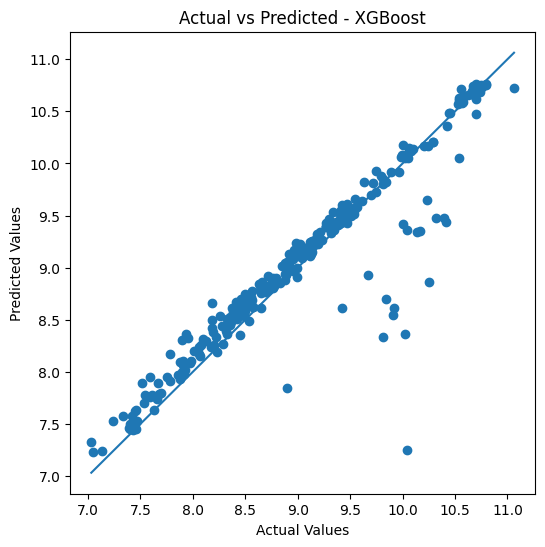

In [76]:
# Xg boost

import matplotlib.pyplot as plt

# Predictions
y_pred_Xgb = xgb.predict(X_test)

# Plot size
plt.figure(figsize=(6,6))

# Scatter points
plt.scatter(y_test, y_pred_Xgb)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

# Labels
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# Title
plt.title("Actual vs Predicted - XGBoost")

plt.show()

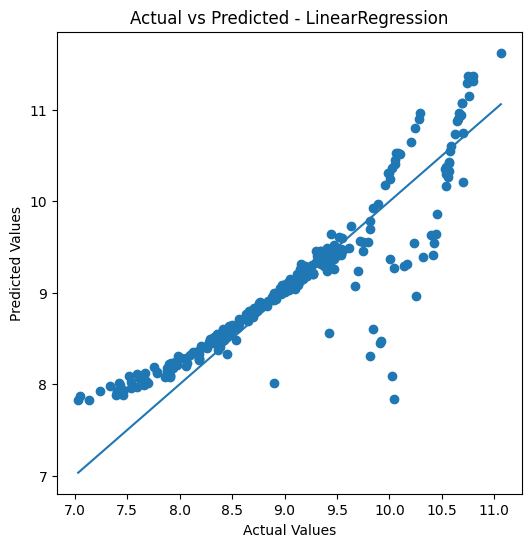

In [77]:
#linear regression

# Predictions
y_pred_lr = model.predict(X_test)

# Plot size
plt.figure(figsize=(6,6))

# Scatter points
plt.scatter(y_test, y_pred_lr)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

# Labels
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# Title
plt.title("Actual vs Predicted - LinearRegression")

plt.show()

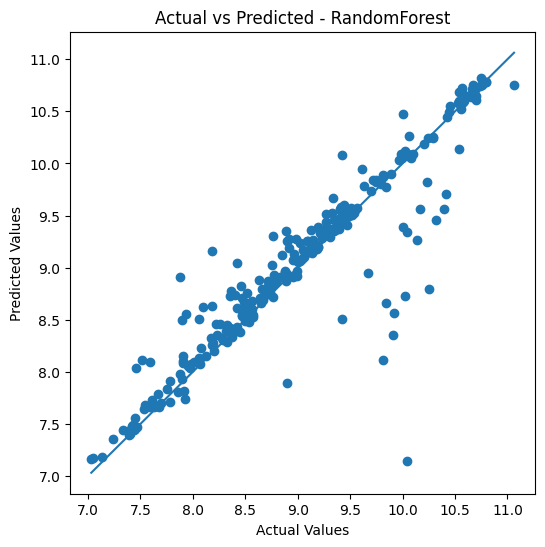

In [78]:
#Random forest regressor

# Predictions
y_pred_RF = regressor.predict(X_test)

# Plot size
plt.figure(figsize=(6,6))

# Scatter points
plt.scatter(y_test, y_pred_RF)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

# Labels
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# Title
plt.title("Actual vs Predicted - RandomForest")

plt.show()

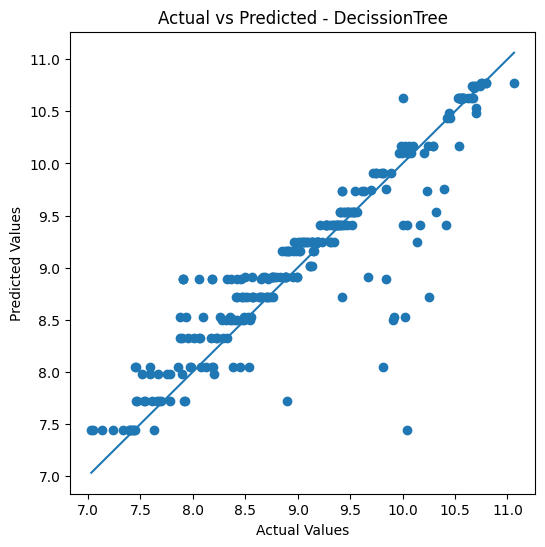

In [79]:
#Decission tree regressor

# Predictions
y_pred_dt = dt.predict(X_test)

# Plot size
plt.figure(figsize=(6,6))

# Scatter points
plt.scatter(y_test, y_pred_dt)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

# Labels
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# Title
plt.title("Actual vs Predicted - DecissionTree")

plt.show()

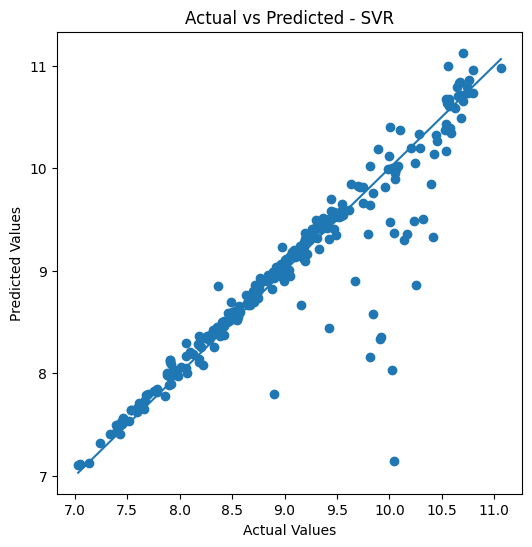

In [80]:
#SVR

# Predictions
y_pred_svr = svr.predict(X_test)

# Plot size
plt.figure(figsize=(6,6))

# Scatter points
plt.scatter(y_test, y_pred_svr)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

# Labels
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# Title
plt.title("Actual vs Predicted - SVR")

plt.show()


**Learn**
*   Encoding using dumies
*   feature engineering to get better results

**Confuse**
*   About choosing column based on feature
*   Why accuracy is too low and model overfitting while data is clean.

**Tomorrow focus**


*   learn more about features of dataset
*   feature angineering and econding







# Dictionary for comparison of all models results.

In [81]:
results = {
    "Linear Regression": {
        "Train R2": Train_r2_lr,
        "Test R2": Test_r2_lr,
        "Train RMSE": Train_rmse_lr,
        "Test RMSE": Test_rmse_lr
    },

    "Ridge Regression": {
        "Train R2": Train_r2_Rg,
        "Test R2": Test_r2_Rg,
        "Train RMSE": Train_rmse_Rg,
        "Test RMSE": Test_rmse_Rg
    },

    "Decision Tree": {
        "Train R2": Train_r2_dt,
        "Test R2": Test_r2_dt,
         "Train RMSE": Train_rmse_dt,
        "Test RMSE": Test_rmse_dt
    },

    "Random Forest": {
        "Train R2": Train_r2_RF,
        "Test R2": Test_r2_RF,
        "Train RMSE": Train_rmse_RF,
        "Test RMSE": Test_rmse_RF
    },

    "XGBoost": {
        "Train R2": Train_r2_Xgb,
        "Test R2": Test_r2_Xgb,
        "Train RMSE": Train_rmse_Xgb,
        "Test RMSE": Test_rmse_Xgb
    },

    "SVR": {
        "Train R2": Train_r2_svr,
        "Test R2": Test_r2_svr,
        "Train RMSE": Train_rmse_svr,
        "Test RMSE": Test_rmse_svr
    }
}

In [82]:
results_df = pd.DataFrame(results).T
print(results_df)

                   Train R2   Test R2  Train RMSE  Test RMSE
Linear Regression  0.774853  0.816451    0.432349   0.406247
Ridge Regression   0.774852  0.816405    0.432350   0.406297
Decision Tree      0.844653  0.832321    0.359131   0.388287
Random Forest      0.967856  0.847372    0.163362   0.370452
XGBoost            0.873299  0.866828    0.324333   0.346035
SVR                0.852969  0.854345    0.349387   0.361889
